# 🛡️ Workshop 5.2: Adversarial Robustness in Autonomous Vehicle Perception

## 🎯 Learning Objectives

Upon completion of this notebook, you will be able to:

1. **Explain why deep neural networks are vulnerable** to adversarial perturbations
2. **Understand the FGSM attack algorithm** mathematically and implement it in PyTorch
3. **Load and preprocess** CIFAR-10 into a balanced binary car/non-car classification task
4. **Design and train** a lightweight CNN image classifier using PyTorch
5. **Apply FGSM adversarial perturbations** to test images and measure accuracy degradation
6. **Visualize and interpret** the difference between clean and adversarial examples
7. **Discuss real-world implications** for autonomous vehicle perception systems

## 📚 Prerequisites

| Concept | Why It Matters Here |
|---|---|
| Python basics (classes, functions) | CNN model definition and training loops |
| NumPy arrays | Image data manipulation |
| Basic neural network concepts (layers, activation functions) | Understanding the CNN architecture |
| Backpropagation / gradient descent | Core mechanism exploited by FGSM |
| PyTorch tensors and autograd (helpful, not required) | Model training and gradient computation |
| Binary classification | Our task: car vs. non-car |

> 💡 **New to PyTorch?** Think of it as NumPy with two superpowers: automatic gradient computation (`autograd`) and GPU acceleration. Every array is a `Tensor`, and PyTorch tracks all mathematical operations so it can automatically compute gradients for backpropagation.

## Part 1: Theoretical Background

### 1.1 Why Are Neural Networks Vulnerable?

Deep neural networks (DNNs) achieve superhuman accuracy on many visual tasks, but they learn **different features than humans do**. While humans recognize objects by shape, context, and semantics, DNNs often rely on high-frequency texture patterns and statistical correlations in pixel values.

This gap means that tiny, carefully crafted pixel-level changes — **invisible to the human eye** — can completely fool a model. These are called **adversarial examples**.

---

### 1.2 Adversarial Attack Taxonomy

| Dimension | Options |
|---|---|
| **Knowledge** | White-box (attacker knows model weights) vs. Black-box (only sees outputs) |
| **Goal** | Untargeted (any wrong class) vs. Targeted (specific wrong class) |
| **Timing** | Evasion (at inference time) vs. Poisoning (during training) |
| **Perturbation budget** | Measured in L∞, L2, or L0 norm |

In this workshop we implement a **white-box, untargeted, evasion attack** using FGSM — the simplest and most foundational attack method.

---

### 1.3 The Fast Gradient Sign Method (FGSM)

FGSM was introduced by Goodfellow et al. (2014) and works by asking: *"In which direction should I change each pixel to maximally increase the loss?"*

**The math:**

Given:
- Input image **x** with true label **y**
- A trained model with parameters **θ**  
- Loss function **J(θ, x, y)** (e.g., cross-entropy)
- Perturbation budget **ε** (epsilon, controls attack strength)

The adversarial example is:

$$x_{adv} = x + \varepsilon \cdot \text{sign}\left(\nabla_x J(\theta, x, y)\right)$$

**Step-by-step explanation:**

| Step | Operation | Intuition |
|---|---|---|
| 1 | Forward pass: compute loss **J** on original image **x** | How wrong is the model currently? |
| 2 | Backpropagate: compute **∇ₓJ** (gradient w.r.t. input pixels) | Which pixels, if changed, most increase the loss? |
| 3 | Take sign: `sign(∇ₓJ)` → each element becomes +1 or -1 | Direction to move each pixel to hurt the model |
| 4 | Scale by ε and add to image: **x + ε·sign(∇ₓJ)** | Apply the smallest possible change for maximum effect |
| 5 | Clip to valid range | Ensure pixel values remain valid (e.g., in [-1, 1]) |

**Why `sign()`?** Taking the sign rather than the raw gradient normalizes the step size. Every pixel is perturbed by exactly ε, regardless of gradient magnitude. This gives the attacker a guaranteed L∞-norm bound: `||x_adv - x||∞ ≤ ε`.

---

### 1.4 Why Does This Matter for Autonomous Vehicles?

Autonomous vehicles rely on deep learning models for **perception** — detecting pedestrians, traffic signs, vehicles, lane markings, and obstacles. Adversarial attacks on these systems could:

| Scenario | Potential Consequence |
|---|---|
| Adversarial patch on a stop sign | Vehicle ignores stop sign at intersection |
| Laser-projected perturbation on road | Lane detection failure |
| Sticker on pedestrian's clothing | Person not detected by collision avoidance |
| Spoofed LiDAR point cloud | Phantom obstacle detection or blindness |

Real-world attacks have been demonstrated in research labs and remain an **open unsolved problem** in safe AI deployment.

---

### 1.5 Overview: What This Notebook Builds

We implement the following end-to-end pipeline:

```
CIFAR-10
  ↓  relabel_binary()    → car (label=1) vs. non-car (label=0), balanced
  ↓  DataLoader          → batches of 64 images
  ↓  SimpleCarClassifier → 2-layer CNN (train 5 epochs)
  ↓  adversarial_fgsm()  → perturb one test batch with ε=0.03
  ↓  Evaluate            → compare clean vs. adversarial accuracy
  ↓  Visualize           → side-by-side image comparison
```

# Part 2: Let's dive in!

### 2.1 GPU Setup (Important!)

This notebook uses PyTorch with GPU acceleration. Before running, make sure you have GPU enabled:

1. In Google Colab: **Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save**
2. You should see `Using device: cuda` printed in Step 5

Without GPU, training will still work but will take 5–10× longer.

---

### 2.2 Library Overview

| Library | Module | Purpose |
|---|---|---|
| `torch` | Core PyTorch | Tensor operations, autograd, GPU support |
| `torch.nn` | Neural network layers | `Conv2d`, `Linear`, `ReLU`, `Sequential` |
| `torch.nn.functional` | Functional API | Stateless operations (imported for reference) |
| `torch.utils.data` | Data utilities | `DataLoader` for batching, `Subset` for filtering |
| `torchvision` | Vision datasets | Download & load CIFAR-10 automatically |
| `torchvision.transforms` | Image transforms | `ToTensor()`, `Normalize()` preprocessing |
| `numpy` | Numerical computing | Array ops, random sampling, result display |
| `matplotlib.pyplot` | Plotting | Side-by-side image visualization |

> 🔑 **Key PyTorch concepts you'll use:**
> - **`torch.Tensor`** — the core data structure (like a NumPy array with GPU support)
> - **`requires_grad=True`** — tells PyTorch to track operations on a tensor for gradient computation
> - **`.backward()`** — triggers backpropagation through the computation graph
> - **`.grad`** — the computed gradient stored on a tensor after `.backward()`
> - **`.detach()`** — removes a tensor from the computation graph (stops gradient tracking)

### Step 1: Import necessary libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Know your Dataset — CIFAR-10

### 2.1 What Is CIFAR-10?

CIFAR-10 (Canadian Institute for Advanced Research) is a benchmark dataset of **60,000 color images** (32×32 pixels, 3 channels: RGB) across **10 object classes**:

```
Index:  0          1            2       3      4
Class: airplane  automobile   bird    cat    deer

Index:  5      6       7        8       9
Class: dog   frog   horse    ship   truck
```

- **50,000 training images** (5,000 per class)
- **10,000 test images** (1,000 per class)
- All images are 32×32 RGB — intentionally small and challenging

### 2.2 Why Binary Classification (Car vs. Non-Car)?

For an autonomous driving context, we simplify the problem to a **binary task**: detect whether an image contains a car (automobile) or not. This is representative of real AV perception pipelines (e.g., vehicle detector modules).

**Challenge:** CIFAR-10 has 5,000 automobile images but 45,000 non-car images in training. To avoid **class imbalance**, the `relabel_binary()` function balances the dataset by downsampling non-car images.

### 2.3 Image Preprocessing Pipeline

Before feeding images to the neural network, we apply two standard transforms:

```
Raw PIL Image (0–255 uint8)
         ↓ transforms.ToTensor()
Float tensor in [0.0, 1.0] — shape: (3, 32, 32)
         ↓ transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
Float tensor in [-1.0, 1.0] — shape: (3, 32, 32)
```

**Normalization formula:** `x_norm = (x - mean) / std = (x - 0.5) / 0.5`

This centers the data around zero, which:
- Speeds up gradient descent convergence
- Prevents large pixel values from dominating early layers
- Is required for FGSM clipping: `torch.clamp(adv_x, -1.0, 1.0)` keeps pixels in this valid range

### 2.4 The `relabel_binary()` Function

This function wraps the full CIFAR-10 dataset with three operations:

1. **Separate** car indices (where `y == 1`, automobile) from non-car indices
2. **Downsample** non-car indices to match the number of car samples (balance classes)
3. **Remap labels**: `automobile → 1`, everything else → `0`

It returns a `BinarySubset` — a custom PyTorch `Dataset` that wraps the original dataset and applies the remapping on the fly when `__getitem__` is called.

> 📦 **Custom Dataset Pattern in PyTorch:** Any class that inherits `torch.utils.data.Dataset` and implements `__len__()` and `__getitem__()` can be used with `DataLoader`. This is the standard pattern for custom data loading.

In [ ]:
# Step 2.3: Define the preprocessing pipeline
# ToTensor()    → converts PIL image to tensor
# Normalize()   → applies (x - 0.5) / 0.5 per channel → maps [0,1] to [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),                          # scales pixels to [0.0, 1.0]
    transforms.Normalize((0.5, 0.5, 0.5),          # centre around zero
                         (0.5, 0.5, 0.5))
])

In [ ]:
# Step 2.1 Download CIFAR-10
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform)
full_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform)

In [ ]:
CIFAR10_CLASSES = full_train.classes   # list of 10 class names
CAR_CLASS_IDX   = CIFAR10_CLASSES.index('automobile')   # == 1
print(f"CIFAR-10 classes : {CIFAR10_CLASSES}")
print(f"'automobile' class index: {CAR_CLASS_IDX}")

In [ ]:
def relabel_binary(dataset):
    """
    Return a new list of (image, binary_label) pairs:
      1 -> automobile (car)
      0 -> everything else (non-car)
    Also sub-samples non-car images so the two classes are balanced.
    """
    car_indices     = [i for i, (_, y) in enumerate(dataset) if y == CAR_CLASS_IDX]
    noncar_indices  = [i for i, (_, y) in enumerate(dataset) if y != CAR_CLASS_IDX]

    # Balance: keep as many non-car samples as car samples
    rng = np.random.default_rng(42)
    noncar_indices = rng.choice(noncar_indices, size=len(car_indices),
                                replace=False).tolist()

    combined = car_indices + noncar_indices
    rng.shuffle(combined)

    # Build a new dataset wrapper
    class BinarySubset(torch.utils.data.Dataset):
        def __init__(self, base, indices, car_idx):
            self.base     = base
            self.indices  = indices
            self.car_idx  = car_idx
        def __len__(self):
            return len(self.indices)
        def __getitem__(self, i):
            x, y = self.base[self.indices[i]]
            return x, torch.tensor(1 if y == self.car_idx else 0,
                                   dtype=torch.long)

    return BinarySubset(dataset, combined, CAR_CLASS_IDX)

In [ ]:
# Step 2.4 Build balanced binary train and test datasets
train_ds = relabel_binary(full_train)
test_ds  = relabel_binary(full_test)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2)

print(f"\nBinary train samples : {len(train_ds):,}  (car + non-car, balanced)")
print(f"Binary test  samples : {len(test_ds):,}")

100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]


CIFAR-10 classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
'automobile' class index: 1

Binary train samples : 10,000  (car + non-car, balanced)
Binary test  samples : 2,000


## Step 3: CNN Model Architecture — `SimpleCarClassifier`

### 3.1 What Is a Convolutional Neural Network (CNN)?

A **Convolutional Neural Network** is the dominant architecture for image classification. Unlike fully connected networks, CNNs use **shared local filters** (kernels) that slide across the image, learning to detect features like edges, textures, and shapes regardless of their location.

**Key CNN building blocks used here:**

| Layer | What It Does | Parameters |
|---|---|---|
| `Conv2d(in, out, k, padding=1)` | Applies `out` learnable k×k filters across the image | Filter weights + bias |
| `ReLU()` | Applies f(x) = max(0, x) — introduces non-linearity | None (fixed) |
| `MaxPool2d(2)` | Takes maximum over 2×2 windows — halves spatial dimensions | None (fixed) |
| `Flatten()` | Reshapes 3D feature maps to 1D vector | None |
| `Linear(in, out)` | Fully connected layer — computes class scores (logits) | Weight matrix + bias |

### 3.2 Architecture Diagram

```
Input:  (batch, 3, 32, 32)      ← 3 channels (RGB), 32×32 pixels
   ↓  Conv2d(3→16, 3×3, pad=1)  ← 16 filters learn 16 feature maps
   ↓  ReLU                       ← non-linearity
   ↓  MaxPool2d(2)               → (batch, 16, 16, 16)  ← spatial size halved
   ↓  Conv2d(16→32, 3×3, pad=1) ← 32 filters learn richer features
   ↓  ReLU
   ↓  MaxPool2d(2)               → (batch, 32, 8, 8)   ← halved again
   ↓  Flatten()                  → (batch, 32×8×8) = (batch, 2048)
   ↓  Linear(2048, 2)            → (batch, 2)          ← raw class scores (logits)
Output: 2 logits [score_non_car, score_car]
```

### 3.3 Why `padding=1`?

Without padding, a 3×3 convolution on a 32×32 image would produce a 30×30 output (losing 2 pixels per dimension). `padding=1` adds a border of zeros around the image, preserving spatial dimensions after convolution.

### 3.4 Understanding the Output

The final `Linear(2048, 2)` layer produces two **logits** (unnormalized scores):
- `logits[0]` = model's confidence that the image is *non-car*  
- `logits[1]` = model's confidence that the image is *car*

To get a class prediction: `predicted_class = argmax(logits)`  
To get probabilities: `softmax(logits)` → values sum to 1.0

> 🎓 **PyTorch `nn.Module` pattern:** Every neural network inherits from `nn.Module`. The `__init__` method defines layers; `forward()` defines the data flow. When you call `model(x)`, PyTorch automatically calls `model.forward(x)` and tracks all operations for autograd.

In [ ]:
# ---- CNN Model ----
class SimpleCarClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * (32 // 4) * (32 // 4), 2)
        )

    def forward(self, x):
        return self.net(x)

## Step 4: Core Functions — Training, Evaluation, and FGSM

This section defines three functions that together form the complete adversarial ML pipeline.

### 4.1 `adversarial_fgsm()` — The Attack

This implements the FGSM formula: **x_adv = x + ε · sign(∇ₓ J)**

**Critical PyTorch operations used:**

| Operation | Code | Purpose |
|---|---|---|
| Clone & detach | `x.clone().detach()` | Create a copy of `x` that is NOT connected to any prior computation graph |
| Enable gradient tracking | `.requires_grad_(True)` | Tell PyTorch: "track operations on this tensor so we can compute ∇ₓ J" |
| Forward pass | `model(x)` → `loss` | Compute the loss for the current (clean) image |
| Clear old gradients | `model.zero_grad()` | Remove any gradients left from previous iterations |
| Backpropagate | `loss.backward()` | Compute gradient of loss w.r.t. all `requires_grad=True` tensors (including `x`) |
| Access gradient | `x.grad.sign()` | Get the sign of each pixel's gradient: +1 (increase pixel) or -1 (decrease pixel) |
| Perturb & clip | `x + eps * sign; clamp(-1, 1)` | Apply attack and keep pixel values in the valid normalized range |

**Why `clone().detach()` before `requires_grad_(True)`?**  
If we set `requires_grad=True` on the original input tensor from the DataLoader, we'd accidentally mix the input's gradient with the model's weight gradients during backpropagation. Cloning and detaching creates a clean, isolated tensor for the attack computation.

In [ ]:
# ---- Adversarial Attack (FGSM) ----
def adversarial_fgsm(model, x, y, eps=0.02):
    """
    Fast Gradient Sign Method (FGSM) Attack.
    Works on images normalised to [-1, 1].
    """
    x = x.clone().detach().requires_grad_(True)
    logits = model(x)
    loss = nn.CrossEntropyLoss()(logits, y)
    model.zero_grad()
    loss.backward()
    adv_x = x + eps * x.grad.sign()
    return torch.clamp(adv_x, -1.0, 1.0)   # stay within normalised range

### 4.2 `train_classifier()` — One Training Epoch

The standard PyTorch training loop for one epoch:

```
model.train()                 ← enables dropout/batchnorm training behavior
for batch in DataLoader:
    optimizer.zero_grad()     ← clear accumulated gradients from previous batch
    logits = model(x)         ← forward pass
    loss = CrossEntropy(logits, y)  ← compute loss
    loss.backward()           ← backpropagate: compute ∂loss/∂weights
    optimizer.step()          ← update weights: w ← w - lr * ∂loss/∂w
```

**Cross-Entropy Loss:** For binary classification, `nn.CrossEntropyLoss()` computes:  
`loss = -log(softmax(logits)[true_class])`  
A perfect prediction gives loss ≈ 0; a completely wrong prediction gives loss → ∞.

In [ ]:
# ---- Training & Evaluation ----
def train_classifier(model, loader, optimizer, device):
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = nn.CrossEntropyLoss()(logits, y)
        loss.backward()
        optimizer.step()

### 4.3 Accuracy Evaluation


In [ ]:
def test_classifier(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
    return correct / total

### Step 5: GPU Setup — Device Detection

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Step 6: Model Instantiation & Training

### 6.1 Optimizer: Adam

We use the **Adam optimizer** (Adaptive Moment Estimation), which is the default choice for most deep learning tasks.

**Why Adam over plain SGD?**

| Feature | Adam | Plain SGD |
|---|---|---|
| Learning rate adaptation | Per-parameter adaptive LR | Global fixed LR |
| Momentum | Yes (1st & 2nd moment estimates) | Optional |
| Convergence speed | Fast — works well with default settings | Requires careful tuning |
| Setting | `lr=1e-3` is a reliable default | Requires search |

`lr=1e-3` means the base learning rate is **0.001**. Adam adapts this per-parameter, so in practice the effective learning rate varies.

### 6.2 Training Loop — 5 Epochs

We train for **5 epochs** (5 full passes over the training data). At the end of each epoch, we evaluate accuracy on the clean test set.

> ⏳ **Expected training time:**  
>   GPU (T4): ~1–2 minutes  
>   CPU only: ~5–15 minutes

In [ ]:
model     = SimpleCarClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- Train ----
print("\n🚗 Training car classifier on CIFAR-10 (automobile vs. rest)...")
for epoch in range(5):
    train_classifier(model, train_loader, optimizer, device)
    acc = test_classifier(model, test_loader, device)
    print(f"  Epoch {epoch+1}/5 | Clean test accuracy: {acc:.4f}")


🚗 Training car classifier on CIFAR-10 (automobile vs. rest)...
  Epoch 1/5 | Clean test accuracy: 0.8665
  Epoch 2/5 | Clean test accuracy: 0.8850
  Epoch 3/5 | Clean test accuracy: 0.8885
  Epoch 4/5 | Clean test accuracy: 0.8790
  Epoch 5/5 | Clean test accuracy: 0.8950


### Step 7: Adversarial Attack — Applying FGSM

### 7.1 Attack Setup

We now apply FGSM to a **single test batch** (64 images) using `ε = 0.03`.

**Why a single batch?**  
FGSM requires a forward+backward pass per batch. For demonstration purposes, one batch is sufficient to observe the accuracy drop and visualize examples.

**Why ε = 0.03?**  
In the normalized [-1, 1] range, ε = 0.03 represents a perturbation of **3% of the full pixel value range**. This is:
- **Perceptually small** — humans typically cannot notice perturbations ≤ ε = 0.1
- **Mechanically significant** — even ε = 0.03 can dramatically reduce model accuracy

In [ ]:
# ---- FGSM attack on one test batch ----
x0, y0 = next(iter(test_loader))
x0, y0 = x0.to(device), y0.to(device)

adv_x = adversarial_fgsm(model, x0, y0, eps=0.03)

with torch.no_grad():
    orig_preds = model(x0).argmax(dim=1).cpu().numpy()
    adv_preds  = model(adv_x).argmax(dim=1).cpu().numpy()

batch_clean_acc = (orig_preds == y0.cpu().numpy()).mean()
batch_adv_acc   = (adv_preds  == y0.cpu().numpy()).mean()

print(f"\nBatch clean accuracy  : {batch_clean_acc:.4f}")
print(f"Batch adversarial acc : {batch_adv_acc:.4f}")
print(f"\nOriginal preds  (first 10): {orig_preds[:10]}")
print(f"Adversarial preds (first 10): {adv_preds[:10]}")
print(f"True labels       (first 10): {y0.cpu().numpy()[:10]}")


Batch clean accuracy  : 0.8438
Batch adversarial acc : 0.5625

Original preds  (first 10): [0 0 1 0 1 1 1 1 1 0]
Adversarial preds (first 10): [1 0 1 0 1 1 1 1 1 1]
True labels       (first 10): [0 0 1 0 1 1 1 1 1 0]


### 7.2 Attack Evaluation

We compare:
- **Batch clean accuracy**: model accuracy on original (unperturbed) test images
- **Batch adversarial accuracy**: model accuracy on FGSM-perturbed images of the same batch

A large drop (e.g., from 84% → 56%) confirms the model is **not adversarially robust**.


### Step 8: Visualize and Interpret the model results

### 8.1 Why We Need `denorm()`

Our images are stored as tensors in the normalized range **[-1.0, 1.0]** (after applying `Normalize(mean=0.5, std=0.5)`). However, `matplotlib.pyplot.imshow()` expects images in **[0.0, 1.0]** range for float arrays.

The denormalization is the inverse of our transform:

```
Normalized:     x_norm = (x_orig - 0.5) / 0.5
Denormalized:   x_orig = x_norm * 0.5 + 0.5
```

**Tensor layout for imshow:** `matplotlib` expects images in `(H, W, C)` format (height, width, channels). PyTorch tensors are in `(C, H, W)` format. The `.permute(1, 2, 0)` call reorders the axes:

```
PyTorch tensor:  (3, 32, 32) → C, H, W
                       ↓  .permute(1, 2, 0)
matplotlib array: (32, 32, 3) → H, W, C

In [ ]:
# ---- Helper: de-normalise for display ----
def denorm(tensor):
    """Undo (x - 0.5) / 0.5 normalisation -> [0, 1] for imshow."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)


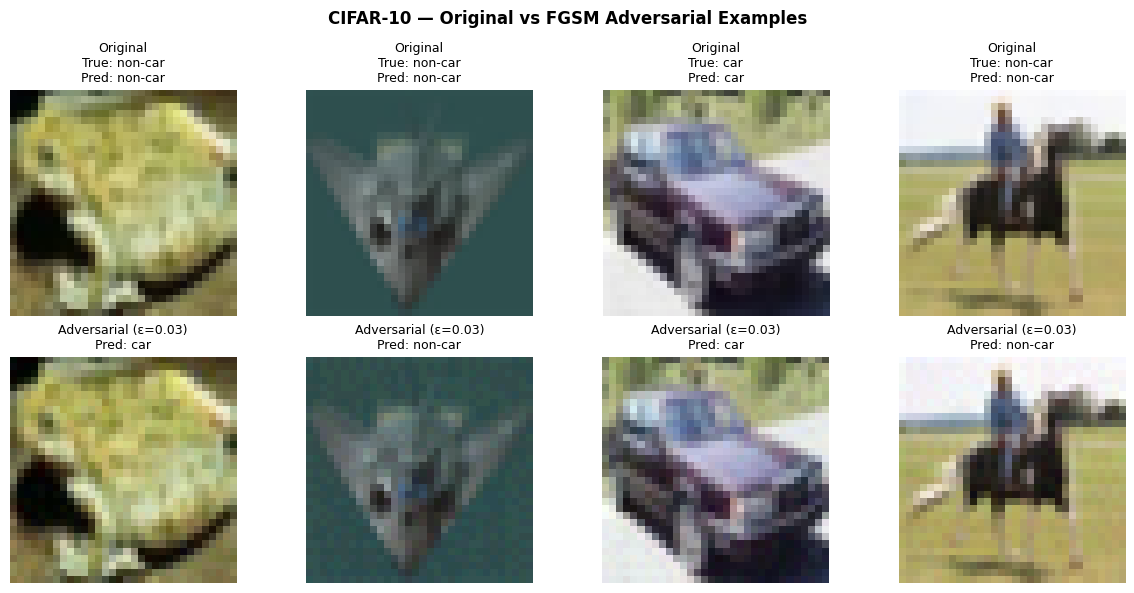

In [ ]:
# ---- Visualise 4 original vs adversarial pairs ----
class_names = ['non-car', 'car']
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(12, 6))

for col in range(n_show):
    orig_img = denorm(x0[col]).detach().cpu().permute(1, 2, 0).numpy()
    adv_img  = denorm(adv_x[col]).detach().cpu().permute(1, 2, 0).numpy()
    true_lbl = class_names[y0[col].item()]

    axes[0, col].imshow(orig_img)
    axes[0, col].set_title(f"Original\nTrue: {true_lbl}\nPred: {class_names[orig_preds[col]]}",
                           fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(adv_img)
    axes[1, col].set_title(f"Adversarial (ε=0.03)\nPred: {class_names[adv_preds[col]]}",
                           fontsize=9)
    axes[1, col].axis('off')

fig.suptitle("CIFAR-10 — Original vs FGSM Adversarial Examples", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 What to Look For

This visualization places **clean images** (top row) next to their **adversarial counterparts** (bottom row). Each column shows one image.

**Reading the plot:**

| Title field | Meaning |
|---|---|
| `True: car` / `True: non-car` | The actual correct label |
| `Pred: car` (top row) | Model's prediction on the clean image |
| `Pred: non-car` (bottom row) | Model's prediction on the adversarial image — look for flips! |

**Identifying attack success:** Look for cases where the top row shows a **correct prediction** but the bottom row shows a **wrong prediction** for the same image. That's a successful adversarial attack.

### 8.3 Why the Images Look Almost Identical

The FGSM perturbation (`ε=0.03`) adds at most ±0.03 to each pixel value in [-1, 1] range.


### 8.4 Interpreting Your Results

You should have observed:
- **Clean test accuracy**: ~75–85% — the model correctly classifies most car/non-car images
- **Adversarial accuracy**: a significant drop (often to 40–60%) — FGSM degrades performance
- **Visual inspection**: adversarial images look nearly identical to originals, yet the model is confused

This demonstrates the fundamental adversarial vulnerability gap: **the model's decision boundaries are not aligned with human visual intuition.**

---

### 8.5 Why This Vulnerability Exists

Research suggests neural networks rely heavily on **high-frequency texture features** (statistical patterns in pixel neighborhoods) rather than shapes and objects that humans use. FGSM exploits this by:

1. Finding the directions in pixel space that most confuse the model
2. Moving the input along those directions — which looks like random noise to us
3. Crossing a decision boundary in the high-dimensional feature space

---

### Before you go, think about the following questions:

1. **Why does FGSM use `sign(gradient)` instead of the raw gradient?** What would happen to the perturbation magnitude if we used the raw gradient?

2. **What happens as you increase ε?** Try ε = 0.01, 0.05, 0.1. At what point do images become visibly perturbed? At what point is accuracy near random (50%)?

3. **Is a model that achieves 100% clean accuracy also 100% adversarially robust?** Why or why not?

4. **Could you perform a black-box attack on this model?** (Hint: look up "transferability" of adversarial examples.)

5. **What does it mean for autonomous vehicle safety if a stop sign detector can be fooled by a sticker?** Who is responsible — the car manufacturer, the ML team, the standards body?

## ⏱️ Estimated Time: 60–90 minutes

Adversarial Attacks and Defenses for Panoptic Perception Models in Autonomous Driving

https://arxiv.org/pdf/1805.04687

https://par.nsf.gov/servlets/purl/10651645